In [1]:
run_dir = "runs/1xrtx3090-moe-no-balancing/"
filename = f"{run_dir}/routing_logits.jsonl"

In [2]:
import json
import re

import torch

In [3]:
step_logits = {}
with open(filename, "r") as f:
    while True:
        line = f.readline()
        if not line:
            break
        logits_data = json.loads(line)
        step = int(logits_data["step"])
        if step not in step_logits:
            if step % 100 == 0:
                print(f"On step {step}")
            step_logits[step] = {}
        name = logits_data["name"]
        layer = int(re.match(r"trf_blocks\.(\d+)\.ff", name).group(1))
        if layer in step_logits[step]:
            raise Exception(f"Multiple layer {layer}s in step {step}")
        routing_logits_list = logits_data["routing_logits"]
        step_logits[step][layer] = torch.tensor(routing_logits_list)

On step 0
On step 100
On step 200
On step 300
On step 400
On step 500
On step 600
On step 700
On step 800
On step 900
On step 1000
On step 1100
On step 1200
On step 1300
On step 1400
On step 1500
On step 1600
On step 1700
On step 1800
On step 1900
On step 2000
On step 2100
On step 2200
On step 2300
On step 2400
On step 2500
On step 2600
On step 2700
On step 2800
On step 2900
On step 3000
On step 3100
On step 3200
On step 3300
On step 3400
On step 3500
On step 3600
On step 3700
On step 3800
On step 3900
On step 4000
On step 4100
On step 4200
On step 4300
On step 4400
On step 4500
On step 4600
On step 4700
On step 4800
On step 4900
On step 5000
On step 5100
On step 5200
On step 5300
On step 5400
On step 5500
On step 5600
On step 5700
On step 5800
On step 5900
On step 6000
On step 6100
On step 6200
On step 6300
On step 6400
On step 6500
On step 6600
On step 6700
On step 6800
On step 6900
On step 7000
On step 7100
On step 7200
On step 7300
On step 7400
On step 7500
On step 7600
On step 770

In [4]:
layers_steps_weights = {}
for step in step_logits:
    for layer in step_logits[step]:
        if layer not in layers_steps_weights:
            layers_steps_weights[layer] = {}
            print(layer)
        layer_logits = step_logits[step][layer]
        layer_weights = torch.softmax(layer_logits, -1)
        batch_size, seq_len, num_experts = layer_weights.shape
        layer_weights_reshaped = layer_weights.view((batch_size * seq_len, num_experts))
        average_weights = layer_weights_reshaped.mean(dim=0)
        layers_steps_weights[layer][step] = average_weights

0
1
2
3
4
5
6
7
8
9
10
11


In [5]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

import numpy as np

In [6]:
plt.xkcd()

font_family = None
for f in font_manager.fontManager.ttflist:
    if "xkcd" in f.name.lower():
        font_family = f.name
        break
if font_family is not None:
    plt.rcParams['font.family'] = font_family

In [12]:
def plot_router_saturation(layer_number, max_yticks=12):
    layer_data = layers_steps_weights[layer_number]
    layer_name = f"LAYER {layer_number}"
    steps = sorted(layer_data.keys())
    weights = np.stack([layer_data[s].detach().cpu().numpy() for s in steps])
    n_steps, n_experts = weights.shape
    uniform = 1.0 / n_experts

    fig, (ax_heat, ax_top) = plt.subplots(
        1, 2, figsize=(12, 6), dpi=100, sharey=True,
        gridspec_kw={"width_ratios": [1.4, 1]},
    )

    # Left: the heatmap, as before
    im = ax_heat.imshow(
        weights,
        aspect="auto",
        cmap="RdYlGn_r",
        vmin=uniform / 2,
        vmax=1.0,
        interpolation="nearest",
    )
    ax_heat.set_xlabel("EXPERT")
    ax_heat.set_ylabel("STEP")
    ax_heat.set_title(f"{layer_name}: EXPERT WEIGHTS")
    ax_heat.set_xticks(range(n_experts))
    ax_heat.set_xticklabels(range(n_experts))

    tick_idx = np.linspace(0, n_steps - 1, min(max_yticks, n_steps), dtype=int)
    ax_heat.set_yticks(tick_idx)
    ax_heat.set_yticklabels([steps[i] for i in tick_idx])

    # Right: top-2 experts per step
    order = np.argsort(-weights, axis=1)   # experts sorted by descending weight
    top1 = order[:, 0]
    top2 = order[:, 1]
    rows = np.arange(n_steps)

    ax_top.scatter(top1, rows, s=12, color="tab:red", label="TOP EXPERT")
    ax_top.scatter(top2, rows, s=12, color="tab:green", label="#2 EXPERT")

    ax_top.set_xlabel("EXPERT")
    ax_top.set_title("TOP-2 EXPERTS")
    ax_top.set_xticks(range(n_experts))
    ax_top.set_xlim(-0.5, n_experts - 0.5)   # match heatmap column positions
    ax_top.invert_yaxis() if False else None  # sharey with imshow already puts step 0 at top

    fig.tight_layout()
    fig.savefig(f"{run_dir}/layer_{layer_number:02}_balance.png")
    return fig, (ax_heat, ax_top)

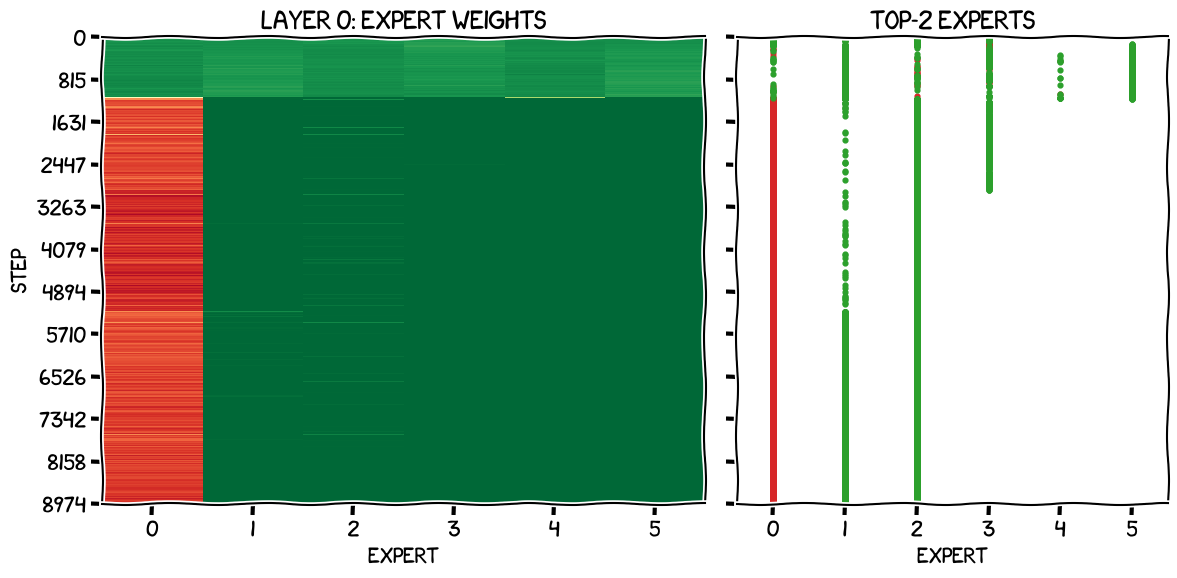

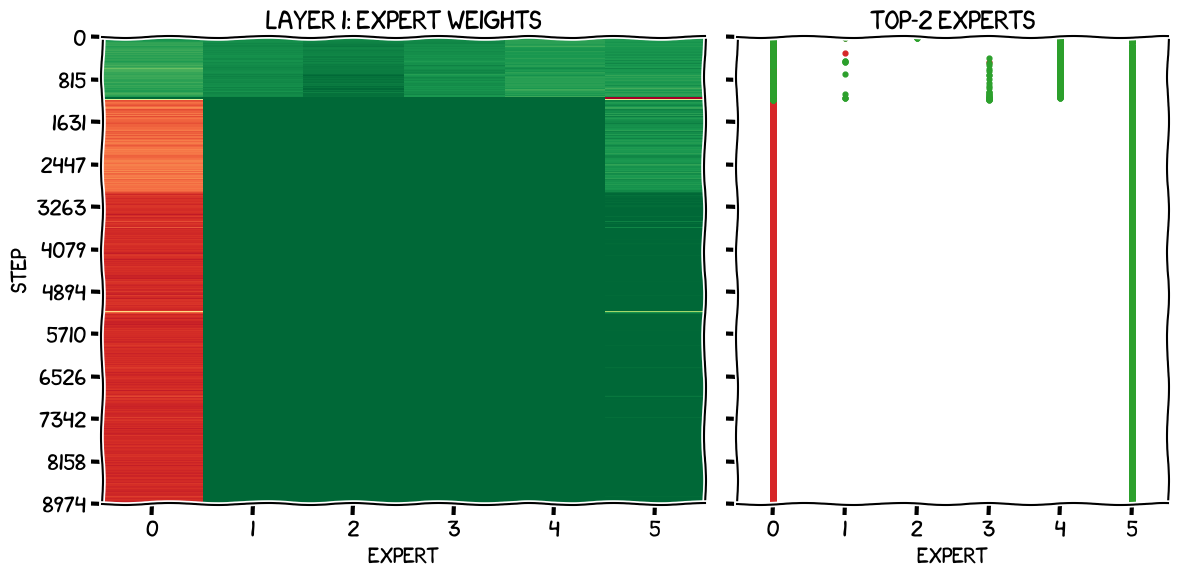

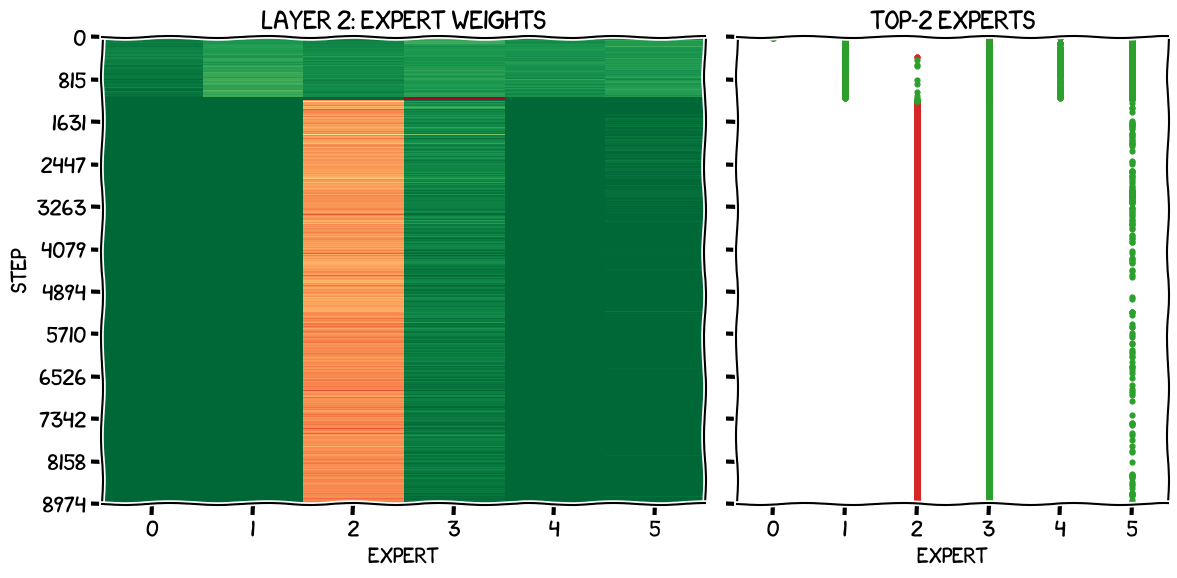

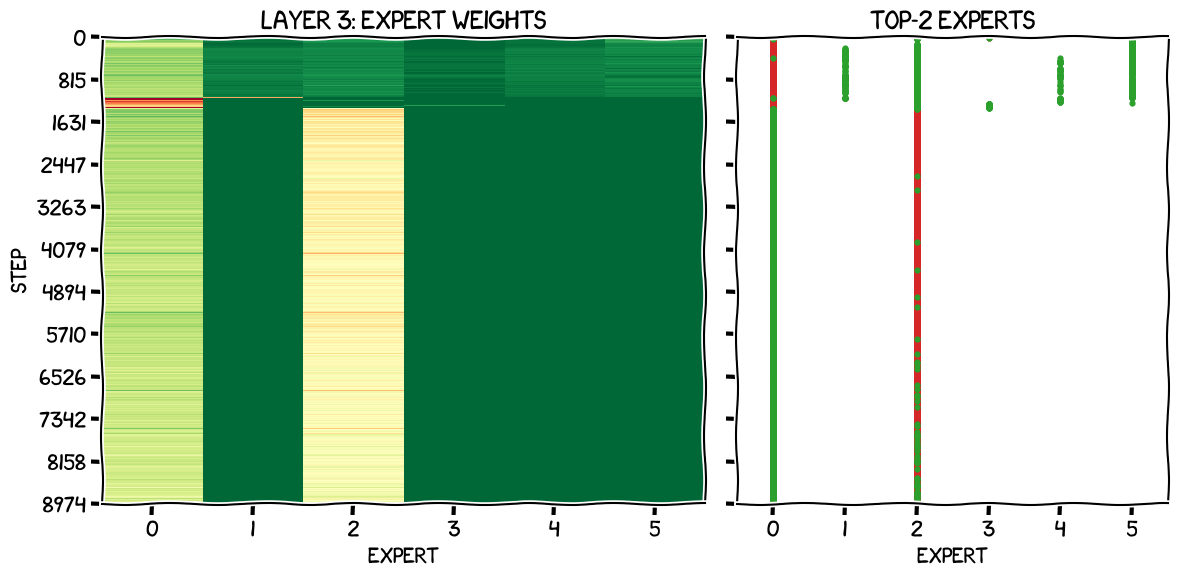

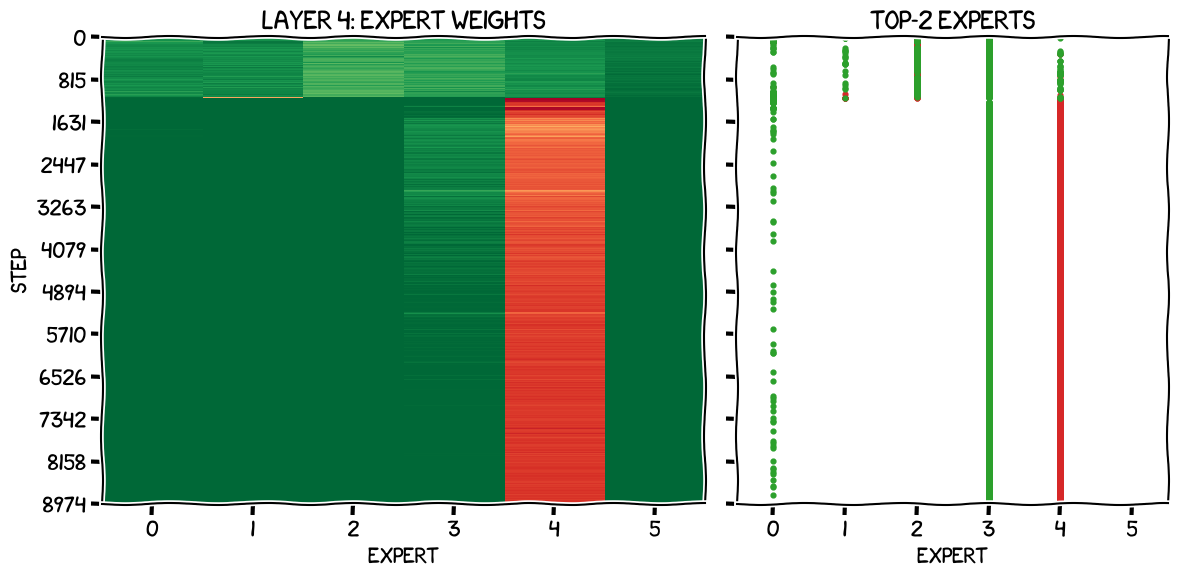

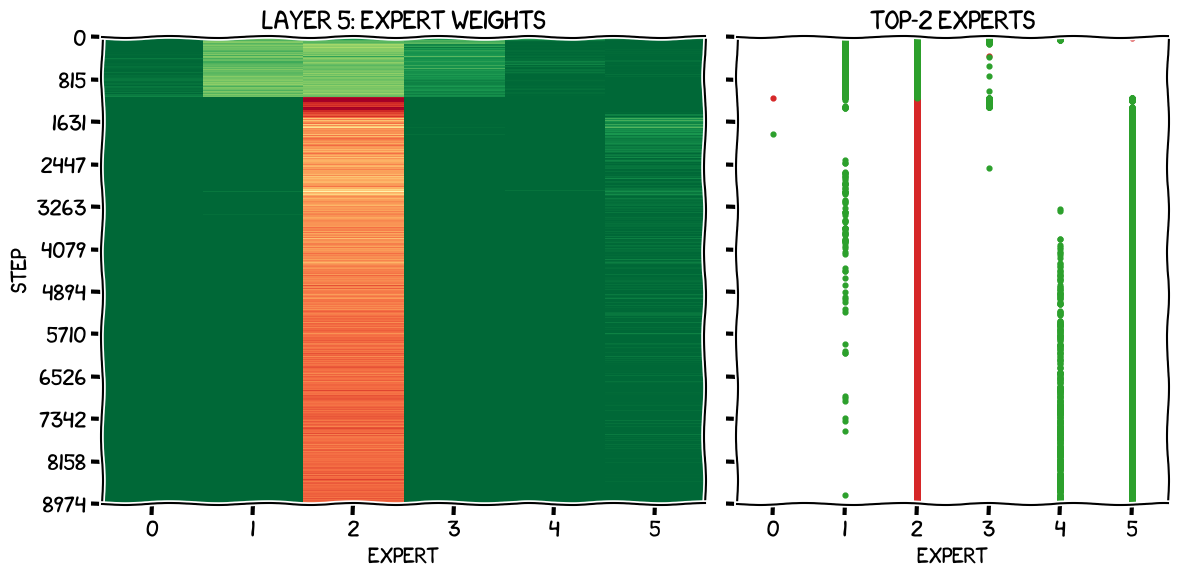

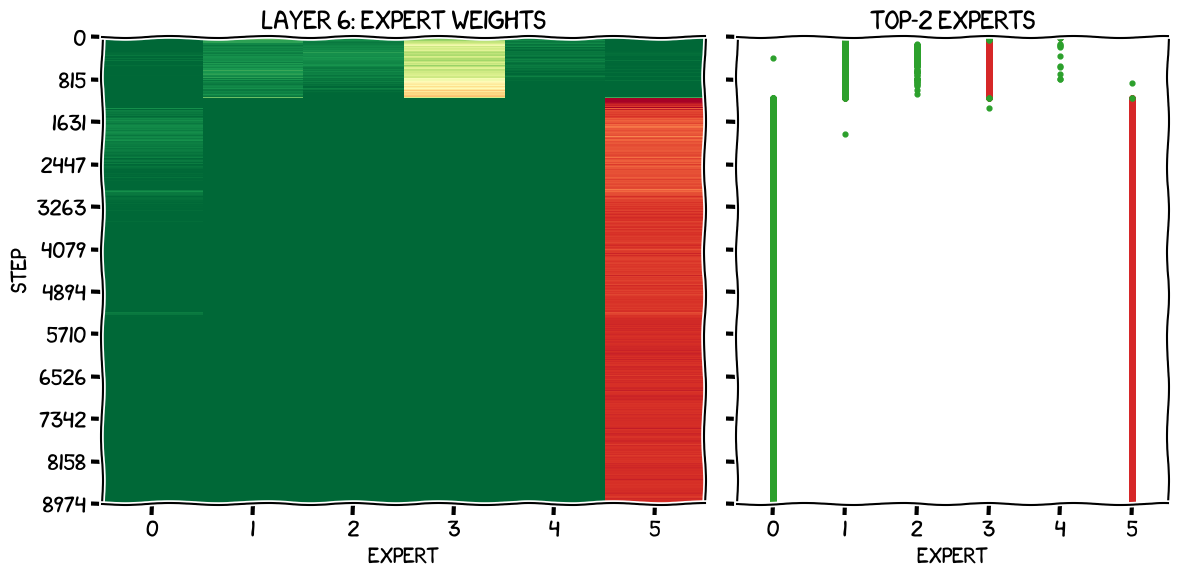

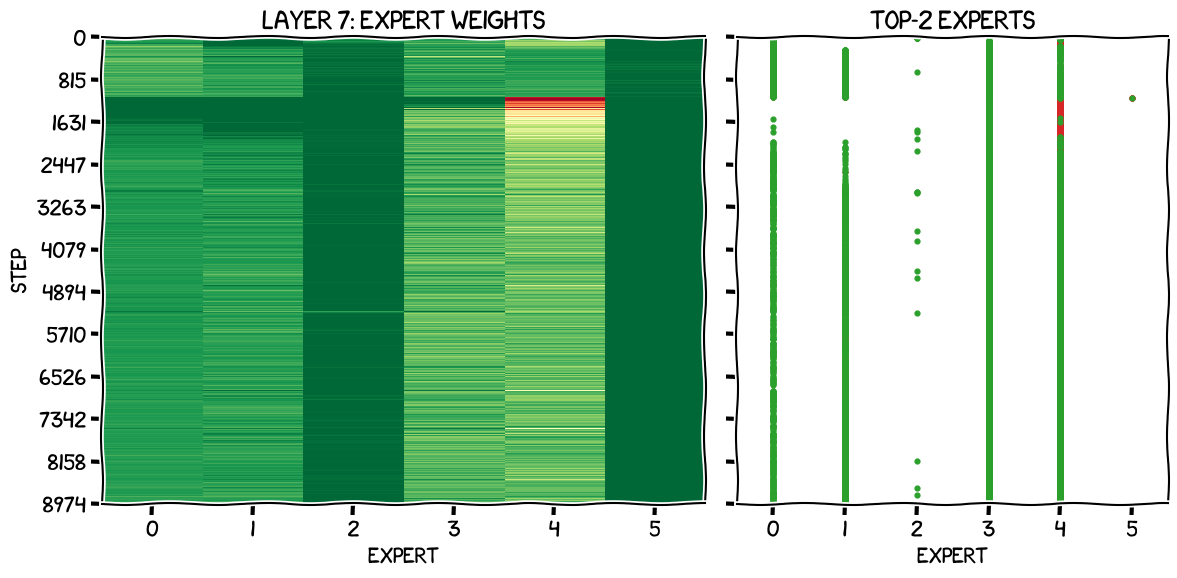

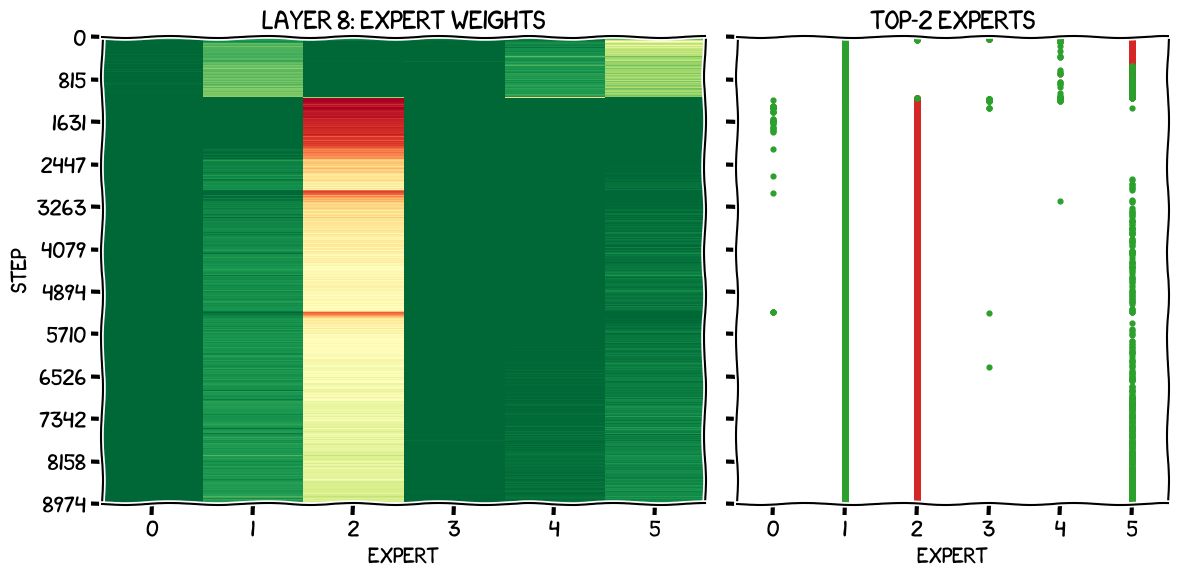

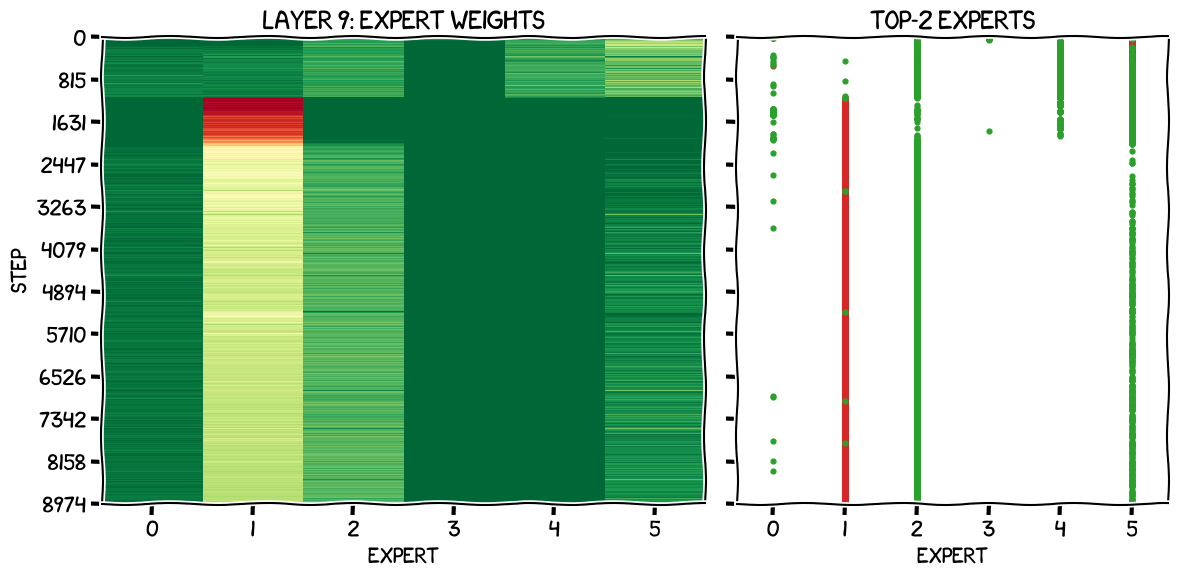

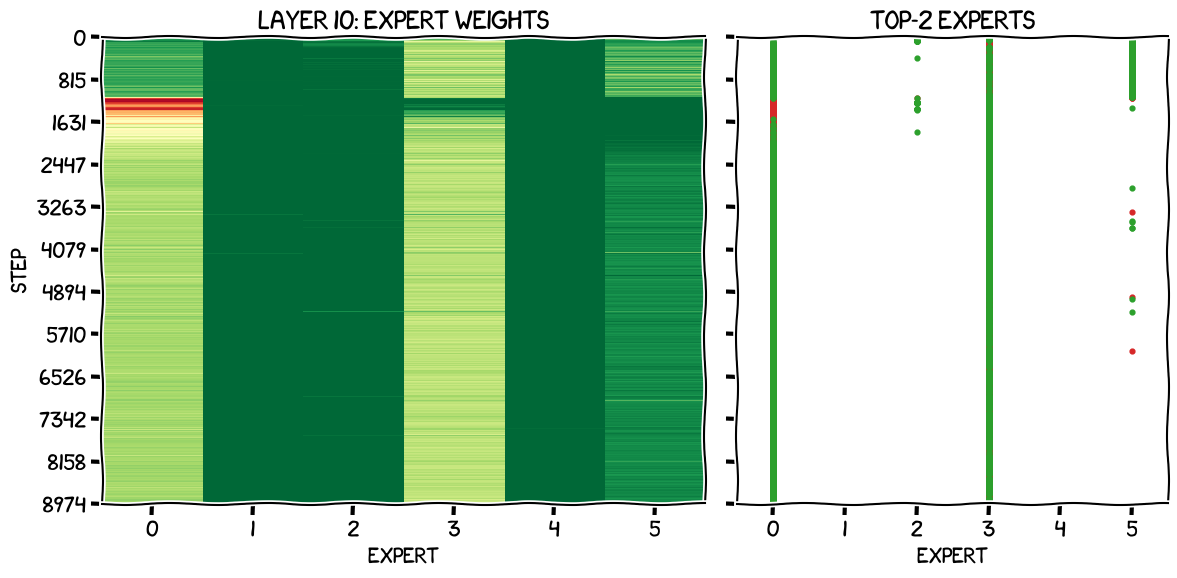

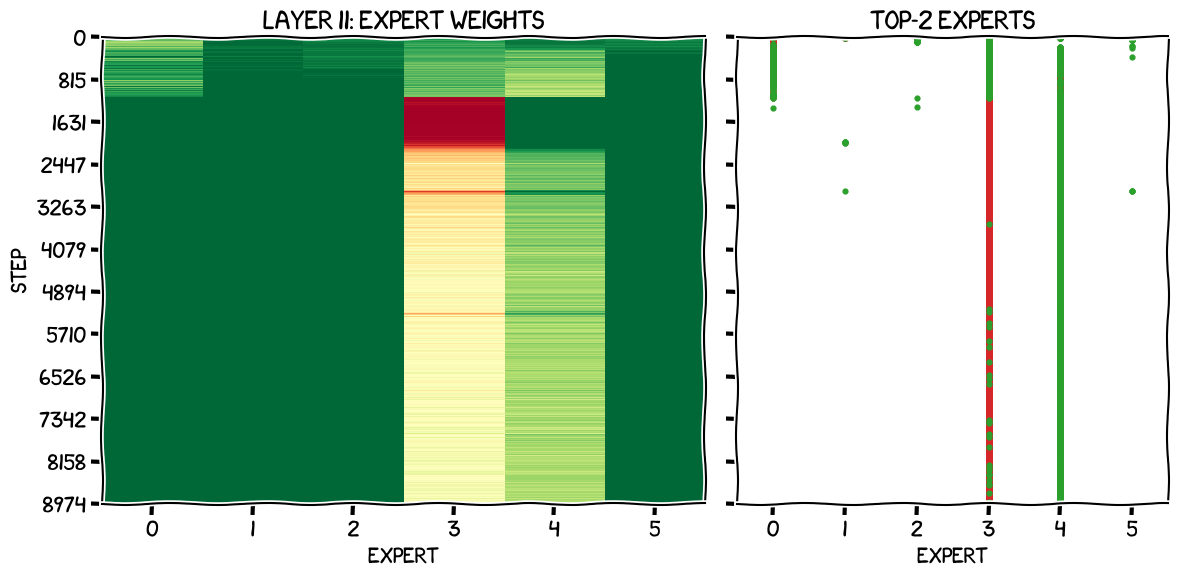

In [13]:
for layer_number in layers_steps_weights:
    fig, ax = plot_router_saturation(layer_number)
    plt.show()